# Phân tích bệnh đái tháo đường và các biến chứng

## 1. Định nghĩa vấn đề
+ **Mô tả**:
    + Bộ dữ liệu bao gồm 768 mẫu là phụ nữ pima indian
    + Mỗi mẫu có 8 đặc điểm: Pregnancies (số lần mang thai), Glucose (nồng độ đường huyết sau khi uống glucose), BloodPressure (huyết áp tâm trương - mm Hg), SkinThickness (độ dày nếp gấp da - mm), Insulin (nồng độ insulin huyết thanh - μU/ml), BMI (chỉ số khối cơ thể), DiabetesPedigreeFunction (chỉ số di truyền tiểu đường), Age (tuổi)

+ **Dữ liệu vào**:
    + Pregnancies
    + Glucose
    + BloodPressure (mm Hg)
    + SkinThickness (mm)
    + Insulin (μU/ml)
    + BMI 
    + DiabetesPedigreeFunction
    + Age
+ **Kết quả**: class (0, 1) trong đó 0 là không bị đái tháo đường và 1 là bị đái tháo đường.

## 2. Chuẩn bị vấn đề

### 2.1 Khai báo thư viện

In [23]:
# load libraries
import pandas as pd
from IPython import display

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np

%matplotlib inline
import warnings
warnings.filterwarnings('ignore')


### 2.2 Nạp dữ liệu 

In [24]:
# Load dataset
data_path = "F:/Study Materials/Môn Ngành/Data Mining - PY/DataMiningPractice/Lab02/pima_indians_diabetes/pima-indians-diabetes.data.csv"
data_names = ["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction","Age","class"]
df_dataset = pd.read_csv(data_path, names = data_names)

## 3. Phân tích dữ liệu

### 3.1 Thống kê mô tả

#### (1) **Hiển thị một số thông tin về dữ liệu**
+ Số dòng, số cột của dữ liệu
+ Kiểu dữ liệu của từng cột
+ 5 dòng đầu và 5 dòng cuối của bảng dữ liệu
+ Thông tin chung về dữ liệu

In [25]:
# shape
print(f'+ shape: {df_dataset.shape}')
# types
print(f'+ Data Types: \n{df_dataset.dtypes}')
# head, tail
print(f'+ Contents: ')
display.display(df_dataset.head(5))
display.display(df_dataset.tail(5))
#ìnfo
df_dataset.info()

+ shape: (768, 9)
+ Data Types: 
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
class                         int64
dtype: object
+ Contents: 


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,class
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   class                     768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


**Nhận xét**:
+ Dữ liệu có 8 tính chất để phân lớp: Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Agr
+ Tổng số dòng dữ liệu là 768 dòng
+ Dữ liệu để phân lớp ở cột class: với 0 = không tiểu đường và 1 = có tiểu đường

#### (2) **Kiểm tra tính toàn vẹn của dữ liệu**
+ Dữ liệu có bị trùng lặp không? Hiển thị dòng bị vi phạm.
+ Dữ liệu có tồn tại giá trị Null không? Hiển thị dòng bị vi phạm.
+ Dữ liệu có tồn tại giá trị NaN không? Hiển thị dòng bị vi phạm.

In [26]:
data_dup = df_dataset.duplicated().sum()
data_null = df_dataset.isnull().sum().any()
data_nan = df_dataset.isna().sum().any()

print(f'Tính toàn vẹn dữ liệu: ')
print(f'+ Số dòng trùng: {data_dup}')
if data_dup>0:
    print(f'+ Duplicates Rows: ')
    print(data_dup)
else:
    print("\nNo duplicated rows found.")
    
print(f'+ Có giá trị Null: {data_null}')
if data_null:
    display.display(df_dataset[df_dataset.isnull().any(axis=1)])
print(f'+ Có giá trị NaN: {data_nan}')
if data_nan:
    display.display(df_dataset[df_dataset.isna().any(axis=1)])

Tính toàn vẹn dữ liệu: 
+ Số dòng trùng: 0

No duplicated rows found.
+ Có giá trị Null: False
+ Có giá trị NaN: False


**Nhật xét**
+ Dữ liệu không có giá trị Null và NaN
+ Dữ liệu không có dòng bị trùng lặp

#### (3) **Các tính chất thống kê trên dữ liệu số**
+ Count, Mean, Standard Deviation, Minimum Value
+ 25th Percentile, 50th Percentile (Median), 75th Percentile, Maximum Value

In [27]:
description = df_dataset.describe().T
display.display(description)

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
class,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


**Nhận xét**


#### (4) **Tần số xuất hiện (Distribution) trên dữ liệu phân lớp (Class) và dữ liệu danh mục (Category)**

Đối với bài toán phân lớp (classification problem), chúng ta cần tính số lần xuất hiện của thuộc tính phân lớp. Điều này là cần thiết cho vấn đề mất cân bằng (highly imbalanced problems) giữa các lớp nhằm cần xử lý đặc biệt trong bước chuẩn bị dữ liệu.

In [28]:
df_dataset["class"].value_counts()

class
0    500
1    268
Name: count, dtype: int64

**Nhận xét**
+ Có sự mất cân bằng lớp nhưng ở mức độ vừa phải.

#### (5) **Mối tương quan giữa các tính chất (Correlations)**

Sự tương quan (correlation) đề cập đến mối quan hệ giữa hai biến và cách chúng có thể có hoặc không cùng nhau thay đổi.

Phương pháp phổ biến nhất để tính toán tương quan là Pearson's Correlation Coeficient, giả định có một phân phối chuẩn của các thuộc tính liên quan. Tương quan -1 hoặc 1 cho thấy mối tương quan âm hoặc dương đầy đủ tương ứng. Trong khi giá trị 0 hiển thị không tương quan ở tất cả. 

$$
r = \frac{\sum_{i=1}^n{\left(x_i - \hat{x}\right)\left(y_i - \hat{y}\right)}}{\sqrt{\sum_{i=1}^n{\left(x_i - \hat{x}\right)^2}\sum_{i=1}^n{\left(y_i - \hat{y}\right)^2}}}
$$

Một số thuật toán học máy như hồi quy tuyến tính và logistic có hiệu suất kém nếu có các thuộc tính tương quan cao trong tập dữ liệu của bạn. 

Như vậy, thật sự cần thiết để xem xét tất cả các mối tương quan theo cặp của các thuộc tính trong tập dữ liệu.

In [29]:
correlations = df_dataset.corr(method='pearson')
display.display(correlations)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,class
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
class,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


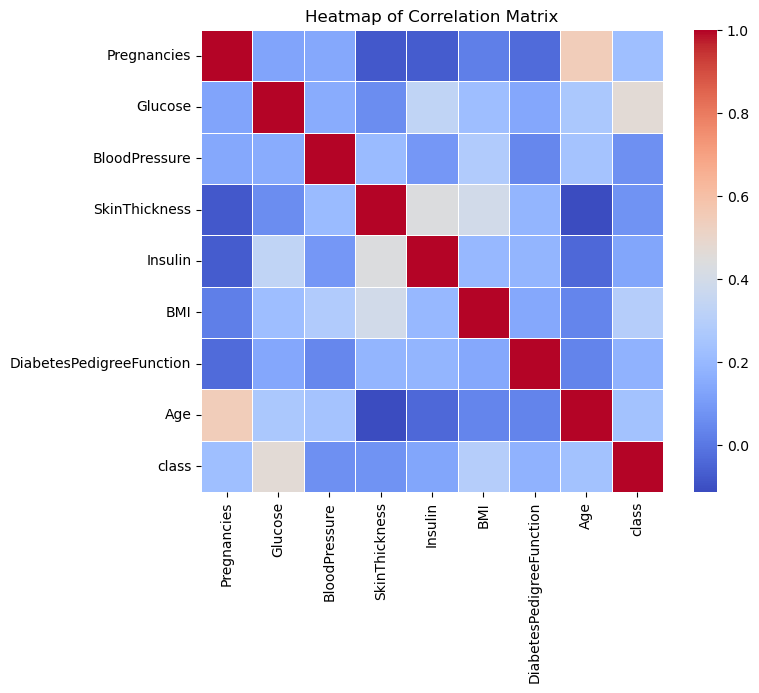

In [30]:
# Tính ma trận tương quan
corr_matrix = df_dataset.corr()

# vẽ biểu đồ heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, cmap='coolwarm', cbar=True, square=True, linewidths=.5)
plt.title('Heatmap of Correlation Matrix')
plt.show()

**Nhận xét**
+ Glucose là biến quan trọng nhất trong dự đoán tiểu đường.
+ BMI, Age, Pregnancies cũng có vai trò nhưng mức độ yếu hơn.
+ Một số biến có sự chồng chéo (multicollinearity), đặc biệt là SkinThickness, BMI, Insulin, vì vậy khi xây mô hình cần chú ý.
+ BloodPressure và DiabetesPedigreeFunction ít tương quan tuyến tính với các biến khác, nhưng có thể vẫn hữu ích theo quan hệ phi tuyến.

### 3.2. Hiển thị dữ liệu

#### (1) Hiển thị trên từng tính chất đơn

**Box and whisker plots**
+ https://www.simplypsychology.org/boxplots.html
+ So sánh các trung vị (median) tương ứng của mỗi ô hộp (box plot). Nếu đường trung vị của một ô hộp nằm bên ngoài ô của một ô hộp so sánh, thì có thể có sự khác biệt giữa hai nhóm.
+ So sánh chiều dài hộp để kiểm tra cách dữ liệu được phân tán giữa mỗi mẫu. Hộp càng dài thì dữ liệu càng phân tán. Dữ liệu càng nhỏ càng ít bị phân tán.
+ Một ngoại lệ (outlier) được định nghĩa là một điểm dữ liệu nằm bên ngoài phần rìa (whiskers) của ô hộp.
+ Kiểm tra hướng lệch của dữ liệu (cân đối, các phần tử tập trung trái, phải).
    + Median ở giữa hộp và râu (whiskers) ở hai bên như nhau thì phân bố là đối xứng.
    + Median ở gần đáy hộp hơn và nếu râu ngắn hơn ở đầu dưới của hộp, thì phân phối là lệch dương (lệch phải).
    + Median ở gần đầu hộp hơn và nếu râu ngắn hơn ở đầu trên của hộp, thì phân bố bị lệch âm (lệch trái).

<Axes: >

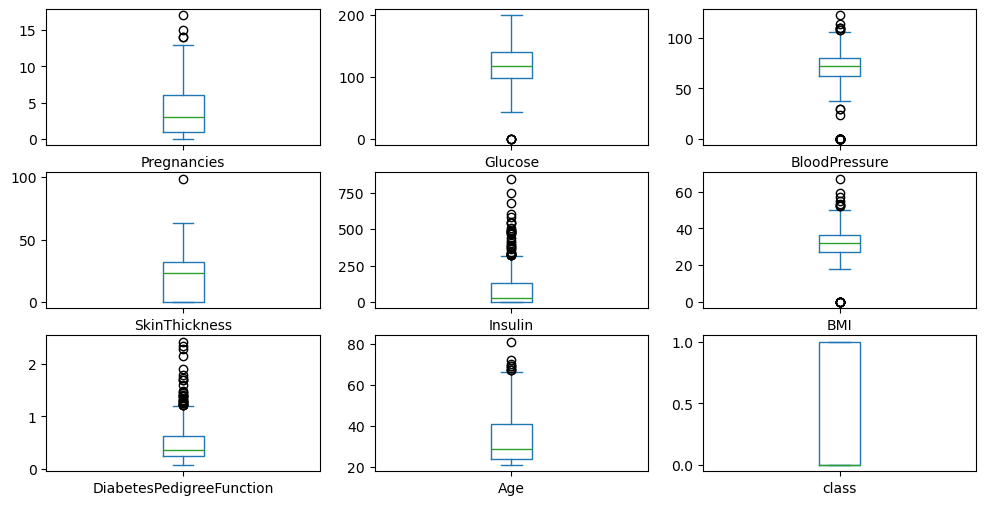

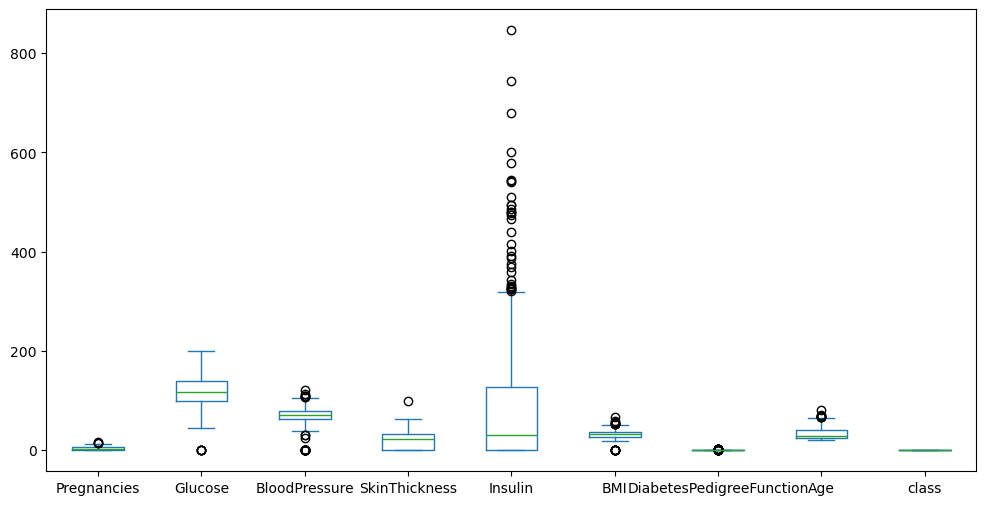

In [31]:
df_dataset.plot(kind="box", subplots=True, layout=(3, 3), sharex=False, sharey=False, figsize=(12,6))
df_dataset.plot(kind="box", figsize=(12,6))

**Nhận xét**
+ Dữ liệu có nhiều giá trị 0 không hợp lý (Glucose, BloodPressure, SkinThickness, Insulin, BMI), vì thế cần xử lý như missing values.
+ Outliers xuất hiện nhiều, đặc biệt ở Insulin và SkinThichness dẫn đến việc có thể là méo phân tích.
+ Phân bố đa phần lệch phải, do đặc trưng dữ liệu y tế (nhiều người có chỉ số thấp - trung bình, ít người có chỉ số rất cao).


**Biểu đồ Histogram**

array([[<Axes: title={'center': 'Pregnancies'}>,
        <Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'SkinThickness'}>,
        <Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'DiabetesPedigreeFunction'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'class'}>]], dtype=object)

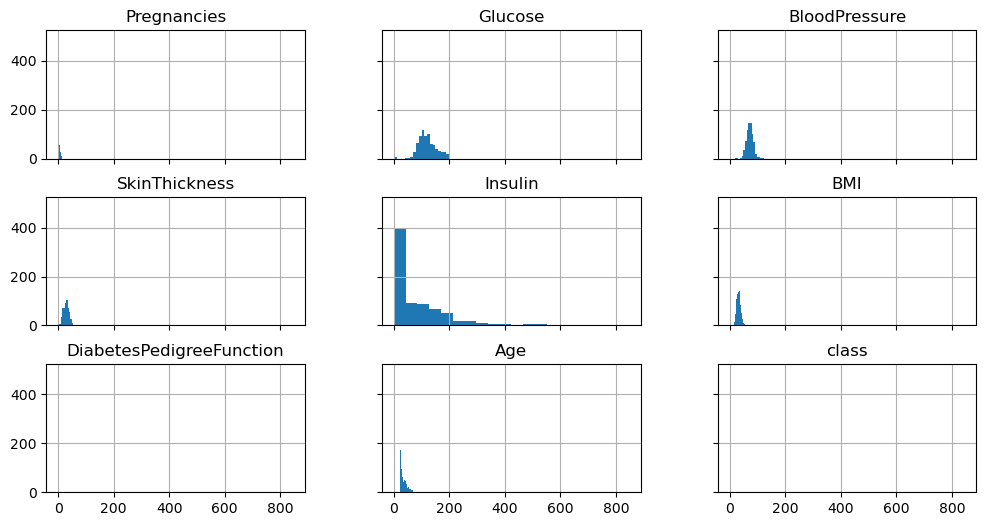

In [32]:
df_dataset.hist(figsize=(12, 6), bins = 20, sharex = True, sharey = True)

#### (2) Hiển thị nhiều tính chất

array([[<Axes: xlabel='Pregnancies', ylabel='Pregnancies'>,
        <Axes: xlabel='Glucose', ylabel='Pregnancies'>,
        <Axes: xlabel='BloodPressure', ylabel='Pregnancies'>,
        <Axes: xlabel='SkinThickness', ylabel='Pregnancies'>,
        <Axes: xlabel='Insulin', ylabel='Pregnancies'>,
        <Axes: xlabel='BMI', ylabel='Pregnancies'>,
        <Axes: xlabel='DiabetesPedigreeFunction', ylabel='Pregnancies'>,
        <Axes: xlabel='Age', ylabel='Pregnancies'>,
        <Axes: xlabel='class', ylabel='Pregnancies'>],
       [<Axes: xlabel='Pregnancies', ylabel='Glucose'>,
        <Axes: xlabel='Glucose', ylabel='Glucose'>,
        <Axes: xlabel='BloodPressure', ylabel='Glucose'>,
        <Axes: xlabel='SkinThickness', ylabel='Glucose'>,
        <Axes: xlabel='Insulin', ylabel='Glucose'>,
        <Axes: xlabel='BMI', ylabel='Glucose'>,
        <Axes: xlabel='DiabetesPedigreeFunction', ylabel='Glucose'>,
        <Axes: xlabel='Age', ylabel='Glucose'>,
        <Axes: xlabel='class', 

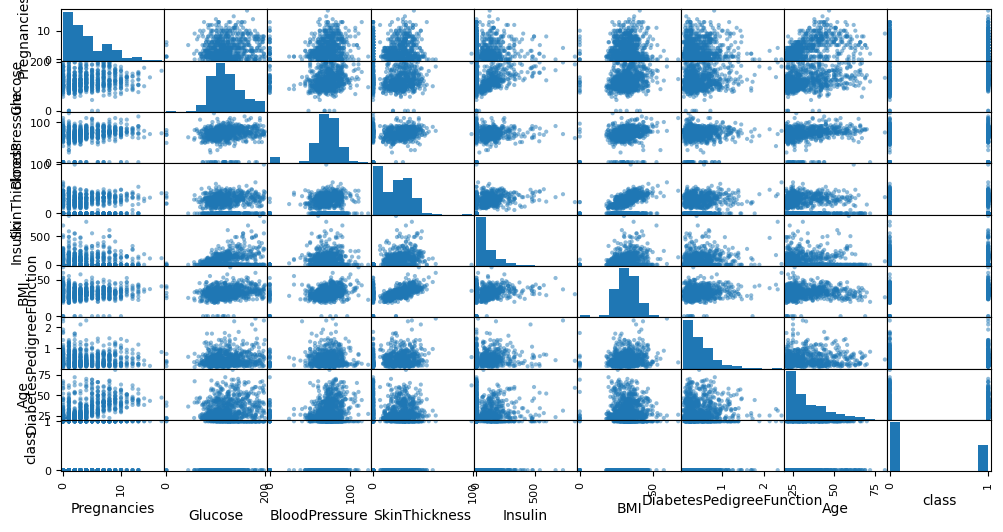

In [33]:
pd.plotting.scatter_matrix(df_dataset, figsize=(12,6))

## 4. Chuẩn bị dữ liệu

### 4.1 Làm sạch dữ liệu

#### (1) **Tạo bảng dữ liệu làm sạch**
+ Chỉ giữ lại các cột Input, Ouput

In [34]:
df_clean = df_dataset.copy()

#### (2) **Xóa dữ liệu trùng nhau**

#### (3) **Xử lý giá trị rỗng, không hợp lệ**

##### Example
Nếu có dữ liệu Null, hay Nan thì chúng ta có các cách giải quyết sau:
+ Chúng ta xóa bỏ cột tính chất vi phạm: 

```python
df_clean.drop("cột_vi_phạm", axis=1)
```
+ Chúng ta xóa bỏ các dòng vi phạm: 

```python
df_clean.dropna(subset=["cột_vi_phạm", ...])
```

+ Điền giá trị hằng số (như số 0), hoặc nội suy bằng phần tử median:

```python
median = df_clean["cột_vi_phạm"].median()
df_clean["cột_vi_phạm"].fillna(median, inplace=True)
```

**Xử lý giá trị 0 không hợp lý**
+ Vì có nhiều giá trị 0 không hợp lý, tức là về mặt logic y khoa thì các cột đó không thể có giá trị bằng 0. Giải pháp là:
1. Thay 0 bằng NaN
2. Điền NaN bằng median vì median ít bị ảnh hưởng bởi outlier.

In [35]:
# xử lý giá trị 0 không hợp lý
cols_with_zero_invalid = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df_clean[cols_with_zero_invalid] = df_clean[cols_with_zero_invalid].replace(0, np.nan)

# Điền NaN bằng median
df_clean[cols_with_zero_invalid] = df_clean[cols_with_zero_invalid].fillna(df_clean[cols_with_zero_invalid].median())

print("Sau khi xử lý giá trị 0:")
print(df_clean.head())


Sau khi xử lý giá trị 0:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6    148.0           72.0           35.0    125.0  33.6   
1            1     85.0           66.0           29.0    125.0  26.6   
2            8    183.0           64.0           29.0    125.0  23.3   
3            1     89.0           66.0           23.0     94.0  28.1   
4            0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction  Age  class  
0                     0.627   50      1  
1                     0.351   31      0  
2                     0.672   32      1  
3                     0.167   21      0  
4                     2.288   33      1  


**Xử lý outliers**
+ Vì Outliers xuất hiện nhiều có thể gây làm méo phân tích nên giải pháp sẽ là chip outliers theo IQR để không mất dữ liệu

In [36]:
# Xử lý outliers
def clip_outliers(series):
    Q1 = series.quantile(0.25) #Q1 là khoảng phân vị thứ 25%
    Q3 = series.quantile(0.75) #Q3 là khoảng phân vị thứ 75%
    IQR = Q3 - Q1 #IQR cho biết phạm vị mà 50% dữ liệu trung tâm nằm trong đó
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return np.clip(series, lower, upper)

for col in df_clean.columns[:-1]:
    df_clean[col] = clip_outliers(df_clean[col])

print("\nSau khi xử lý outliers (clip theo IQR):")
print(df_clean.head())


Sau khi xử lý outliers (clip theo IQR):
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0          6.0    148.0           72.0           35.0  125.000  33.6   
1          1.0     85.0           66.0           29.0  125.000  26.6   
2          8.0    183.0           64.0           29.0  125.000  23.3   
3          1.0     89.0           66.0           23.0  112.875  28.1   
4          0.0    137.0           40.0           35.0  135.875  43.1   

   DiabetesPedigreeFunction   Age  class  
0                     0.627  50.0      1  
1                     0.351  31.0      0  
2                     0.672  32.0      1  
3                     0.167  21.0      0  
4                     1.200  33.0      1  


### 4.2 Biến đổi dữ liệu

#### (1) Chuyển đổi dữ liệu danh mục (Category) thành dữ liệu số

#### (2) Chuyển đổi dữ liệu danh mục (Category) thành dạng OneHot

Một số thuật toán khi chuyển đổi cột dạng danh mục thành kiểu OneHot thì cho hiệu suất cao hơn. 

Bên cạnh đó, khi huấn luyện mô hình với dạng hàm mất mát CategoryEntropy thì cũng cần chuyển thuộc tính phân lớp sang dạng OneHot.

#### (3) Chuẩn hóa dữ liệu (Data Normalize)

Chuẩn hóa các tính chất để đưa về cùng một miền trị
+ Min-Max Normalization
$$
z = \frac{x - min(x)}{max(x) - min(x)}
$$
+ Standard Normalization
$$
z = \frac{x - \mu}{\sigma}
$$

**Lưu ý**: Quá trình chuẩn hóa có thể làm trong phần thực nghiệm thuật toán

In [37]:
# Min-Max Normalization
scale_columns = ["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction","Age"]
minmax_scaler = MinMaxScaler()
minmax_scaler.fit(df_clean[scale_columns])
df_clean_minmax = df_clean.copy()
df_clean_minmax[scale_columns] = minmax_scaler.transform(df_clean[scale_columns])
df_clean_minmax

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,class
0,0.444444,0.670968,0.50000,0.732143,0.527174,0.480499,0.489305,0.637363,1
1,0.074074,0.264516,0.40625,0.517857,0.527174,0.262090,0.243316,0.219780,0
2,0.592593,0.896774,0.37500,0.517857,0.527174,0.159126,0.529412,0.241758,1
3,0.074074,0.290323,0.40625,0.303571,0.000000,0.308892,0.079323,0.000000,0
4,0.000000,0.600000,0.00000,0.732143,1.000000,0.776911,1.000000,0.263736,1
...,...,...,...,...,...,...,...,...,...
763,0.740741,0.367742,0.56250,1.000000,1.000000,0.458658,0.082888,0.923077,0
764,0.148148,0.503226,0.46875,0.446429,0.527174,0.580343,0.233512,0.131868,0
765,0.370370,0.496774,0.50000,0.303571,0.000000,0.249610,0.148841,0.197802,0
766,0.074074,0.529032,0.31250,0.517857,0.527174,0.371295,0.241533,0.571429,1


<Axes: >

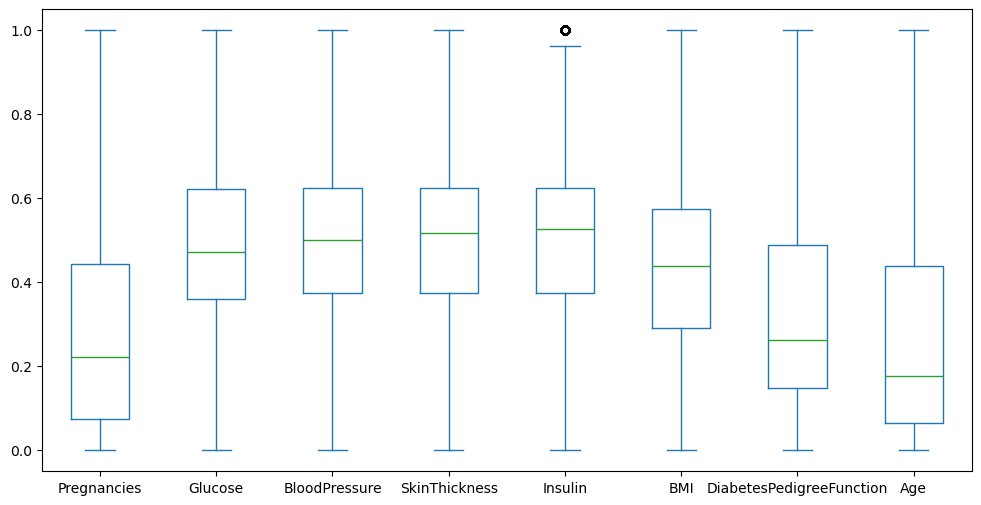

In [38]:
df_clean_minmax[scale_columns].plot(kind="box", figsize=(12,6))

In [39]:
# Standard Normalization
standard_scaler = StandardScaler()
standard_scaler.fit(df_clean[scale_columns])
df_clean_standard = df_clean.copy()
df_clean_standard[scale_columns] = standard_scaler.transform(df_clean[scale_columns])
df_clean_standard

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,class
0,0.647150,0.866045,-0.030632,0.824667,0.039062,0.181092,0.588927,1.445691,1
1,-0.848970,-1.205066,-0.543914,0.017945,0.039062,-0.869465,-0.378101,-0.189304,0
2,1.245598,2.016662,-0.715008,0.017945,0.039062,-1.364728,0.746595,-0.103252,1
3,-0.848970,-1.073567,-0.543914,-0.788777,-1.494110,-0.644346,-1.022787,-1.049828,0
4,-1.148194,0.504422,-2.768136,0.824667,1.414175,1.606849,2.596563,-0.017199,1
...,...,...,...,...,...,...,...,...,...
763,1.844045,-0.679069,0.311556,1.833069,1.414175,0.076036,-1.008772,2.564372,0
764,-0.549746,0.011301,-0.201726,-0.250963,0.039062,0.661347,-0.416642,-0.533513,0
765,0.347926,-0.021574,-0.030632,-0.788777,-1.494110,-0.929497,-0.749497,-0.275356,0
766,-0.848970,0.142800,-1.057196,0.017945,0.039062,-0.344187,-0.385109,1.187534,1


<Axes: >

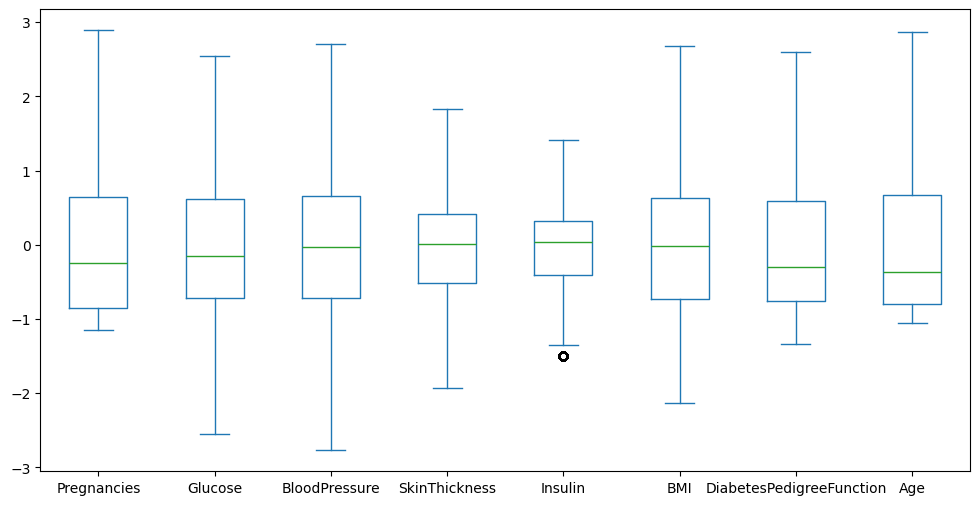

In [40]:
df_clean_standard[scale_columns].plot(kind="box", figsize=(12,6))

In [41]:
correlations = df_clean_standard.corr(method='pearson')
display.display(correlations)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,class
Pregnancies,1.000000,0.126856,0.210906,0.110471,0.097060,0.027159,-0.017398,0.549695,0.220392
Glucose,0.126856,1.000000,0.220199,0.181371,0.413981,0.233590,0.118457,0.268912,0.492782
BloodPressure,0.210906,0.220199,1.000000,0.204136,0.107028,0.286543,0.012305,0.332898,0.168971
SkinThickness,0.110471,0.181371,0.204136,1.000000,0.200742,0.559843,0.073051,0.125169,0.220111
Insulin,0.097060,0.413981,0.107028,0.200742,1.000000,0.184982,0.089418,0.170824,0.266382
BMI,0.027159,0.233590,0.286543,0.559843,0.184982,1.000000,0.138378,0.035697,0.312811
DiabetesPedigreeFunction,-0.017398,0.118457,0.012305,0.073051,0.089418,0.138378,1.000000,0.047289,0.184969
Age,0.549695,0.268912,0.332898,0.125169,0.170824,0.035697,0.047289,1.000000,0.242702
class,0.220392,0.492782,0.168971,0.220111,0.266382,0.312811,0.184969,0.242702,1.000000


### (4) Chia dữ liệu thực nghiệm

+ Chuyển đổi dữ liệu sang dạng numpy với phần Input (X_data), Output (y_data)
+ Chia dữ liệu thành tập train/test (tỷ lệ 70/30)
+ Lưu tất cả thông tin để chuẩn bị chạy thuật toán

In [42]:
X_data, Y_data = df_clean.values[:, :-1], df_clean.values[:, -1]
X_data.shape, Y_data.shape
print(X_data[:20, :])
print(Y_data[:20])

[[6.00000e+00 1.48000e+02 7.20000e+01 3.50000e+01 1.25000e+02 3.36000e+01
  6.27000e-01 5.00000e+01]
 [1.00000e+00 8.50000e+01 6.60000e+01 2.90000e+01 1.25000e+02 2.66000e+01
  3.51000e-01 3.10000e+01]
 [8.00000e+00 1.83000e+02 6.40000e+01 2.90000e+01 1.25000e+02 2.33000e+01
  6.72000e-01 3.20000e+01]
 [1.00000e+00 8.90000e+01 6.60000e+01 2.30000e+01 1.12875e+02 2.81000e+01
  1.67000e-01 2.10000e+01]
 [0.00000e+00 1.37000e+02 4.00000e+01 3.50000e+01 1.35875e+02 4.31000e+01
  1.20000e+00 3.30000e+01]
 [5.00000e+00 1.16000e+02 7.40000e+01 2.90000e+01 1.25000e+02 2.56000e+01
  2.01000e-01 3.00000e+01]
 [3.00000e+00 7.80000e+01 5.00000e+01 3.20000e+01 1.12875e+02 3.10000e+01
  2.48000e-01 2.60000e+01]
 [1.00000e+01 1.15000e+02 7.20000e+01 2.90000e+01 1.25000e+02 3.53000e+01
  1.34000e-01 2.90000e+01]
 [2.00000e+00 1.97000e+02 7.00000e+01 4.25000e+01 1.35875e+02 3.05000e+01
  1.58000e-01 5.30000e+01]
 [8.00000e+00 1.25000e+02 9.60000e+01 2.90000e+01 1.25000e+02 3.23000e+01
  2.32000e-01 5.4

In [43]:
X_train, X_test, Y_train, Y_test = train_test_split(X_data, Y_data, train_size=0.7)
print(f'+ Train/Test: Train Ratio = {len(X_train)/len(X_data)}')
print(f'+ Train: shape = {X_train.shape}\nInput = \n{X_train[:5]}\nOutput = {Y_train[:5]}')
print(f'+ Test: shape = {X_test.shape}\nInput = \n{X_test[:5]}\nOutput = {Y_test[:5]}')

+ Train/Test: Train Ratio = 0.69921875
+ Train: shape = (537, 8)
Input = 
[[  8.    194.     80.     29.    125.     26.1     0.551  66.5  ]
 [  3.    191.     68.     15.    130.     30.9     0.299  34.   ]
 [  4.     99.     72.     17.    125.     25.6     0.294  28.   ]
 [  1.    180.     72.     29.    125.     43.3     0.282  41.   ]
 [  3.    130.     78.     23.    112.875  28.4     0.323  34.   ]]
Output = [0. 0. 0. 1. 1.]
+ Test: shape = (231, 8)
Input = 
[[6.00000e+00 1.51000e+02 6.20000e+01 3.10000e+01 1.20000e+02 3.55000e+01
  6.92000e-01 2.80000e+01]
 [2.00000e+00 9.50000e+01 5.40000e+01 1.45000e+01 1.12875e+02 2.61000e+01
  7.48000e-01 2.20000e+01]
 [3.00000e+00 9.90000e+01 5.40000e+01 1.90000e+01 1.12875e+02 2.56000e+01
  1.54000e-01 2.40000e+01]
 [8.00000e+00 1.55000e+02 6.20000e+01 2.60000e+01 1.35875e+02 3.40000e+01
  5.43000e-01 4.60000e+01]
 [1.00000e+01 1.79000e+02 7.00000e+01 2.90000e+01 1.25000e+02 3.51000e+01
  2.00000e-01 3.70000e+01]]
Output = [0. 0. 0. 1. 0.

# Kết Thúc